# 💼 Data Science Job Salaries — Exploratory Data Analysis

### Analyzing Salary Trends by Experience, Work Type, Job Title, and Location

**Tools:** Python | Pandas | NumPy | Matplotlib | Seaborn

## Objective

To analyze job salary data and identify patterns and trends based on
experience level, employment type, job title, and location.

In [190]:
import zipfile

zip_path = "/content/archive.zip"
extract_path = "/content/linkedin_data"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [191]:
import pandas as pd
file_path = "/content/linkedin_data/postings.csv"
jobs = pd.read_csv(file_path)
print("Dataset loaded successfully!")
print("number of rowes:", len(jobs))
print("number of columns:",len(jobs.columns))

Dataset loaded successfully!
number of rowes: 123849
number of columns: 31


In [192]:
jobs.head()

,job_id,company_name,title,description,max_salary,pay_period,location,company_id,views,med_salary,...,skills_desc,listed_time,posting_domain,sponsored,work_type,currency,compensation_type,normalized_salary,zip_code,fips
0,921716,Corcoran Sawyer Smith,Marketing Coordinator,Job descriptionA leading real estate firm in N...,20.0,HOURLY,"Princeton, NJ",2774458.0,20.0,NaN,...,Requirements: \n\nWe are seeking a College or ...,1.713398e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,38480.0,8540.0,34021.0
1,1829192,NaN,Mental Health Therapist/Counselor,"At Aspen Therapy and Wellness , we are committ...",50.0,HOURLY,"Fort Collins, CO",NaN,1.0,NaN,...,NaN,1.712858e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,83200.0,80521.0,8069.0
2,10998357,The National Exemplar,Assitant Restaurant Manager,The National Exemplar is accepting application...,65000.0,YEARLY,"Cincinnati, OH",64896719.0,8.0,NaN,...,We are currently accepting resumes for FOH - A...,1.713278e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,55000.0,45202.0,39061.0
3,23221523,"Abrams Fensterman, LLP",Senior Elder Law / Trusts and Estates Associat...,Senior Associate Attorney - Elder Law / Trusts...,175000.0,YEARLY,"New Hyde Park, NY",766262.0,16.0,NaN,...,This position requires a baseline understandin...,1.712896e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,157500.0,11040.0,36059.0
4,35982263,NaN,Service Technician,Looking for HVAC service tech with experience ...,80000.0,YEARLY,"Burlington, IA",NaN,3.0,NaN,...,NaN,1.713452e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,70000.0,52601.0,19057.0


In [193]:

print("Shape:", jobs.shape)

print("\nColumn names:")
print(jobs.columns.tolist())

print("\nData types:")
print(jobs.dtypes)

print("\nMissing values:")
print(jobs.isnull().sum().sort_values(ascending=False).head(15))

Shape: (123849, 31)

Column names:
['job_id', 'company_name', 'title', 'description', 'max_salary', 'pay_period', 'location', 'company_id', 'views', 'med_salary', 'min_salary', 'formatted_work_type', 'applies', 'original_listed_time', 'remote_allowed', 'job_posting_url', 'application_url', 'application_type', 'expiry', 'closed_time', 'formatted_experience_level', 'skills_desc', 'listed_time', 'posting_domain', 'sponsored', 'work_type', 'currency', 'compensation_type', 'normalized_salary', 'zip_code', 'fips']

Data types:
job_id                          int64
company_name                   object
title                          object
description                    object
max_salary                    float64
pay_period                     object
location                       object
company_id                    float64
views                         float64
med_salary                    float64
min_salary                    float64
formatted_work_type            object
applies          

In [194]:

clean_salary_data = jobs.copy()
conversion = {
    "YEARLY": 1,
    "MONTHLY": 12,
    "WEEKLY": 52,
    "BIWEEKLY": 26,
    "HOURLY": 2080
}

clean_salary_data["annual_min_salary"] = (
    clean_salary_data["min_salary"] *
    clean_salary_data["pay_period"].map(conversion)
)

clean_salary_data["annual_max_salary"] = (
    clean_salary_data["max_salary"] *
    clean_salary_data["pay_period"].map(conversion)
)

clean_salary_data = clean_salary_data[
    clean_salary_data["annual_max_salary"].notna()
]

print("Clean salary data created successfully!")
print("Rows:", len(clean_salary_data))
print("Columns:", len(clean_salary_data.columns))

clean_salary_data[
    [
        "title",
        "location",
        "pay_period",
        "min_salary",
        "max_salary",
        "annual_min_salary",
        "annual_max_salary"
    ]
].head()

Clean salary data created successfully!
Rows: 29793
Columns: 33


,title,location,pay_period,min_salary,max_salary,annual_min_salary,annual_max_salary
0,Marketing Coordinator,"Princeton, NJ",HOURLY,17.0,20.0,35360.0,41600.0
1,Mental Health Therapist/Counselor,"Fort Collins, CO",HOURLY,30.0,50.0,62400.0,104000.0
2,Assitant Restaurant Manager,"Cincinnati, OH",YEARLY,45000.0,65000.0,45000.0,65000.0
3,Senior Elder Law / Trusts and Estates Associat...,"New Hyde Park, NY",YEARLY,140000.0,175000.0,140000.0,175000.0
4,Service Technician,"Burlington, IA",YEARLY,60000.0,80000.0,60000.0,80000.0


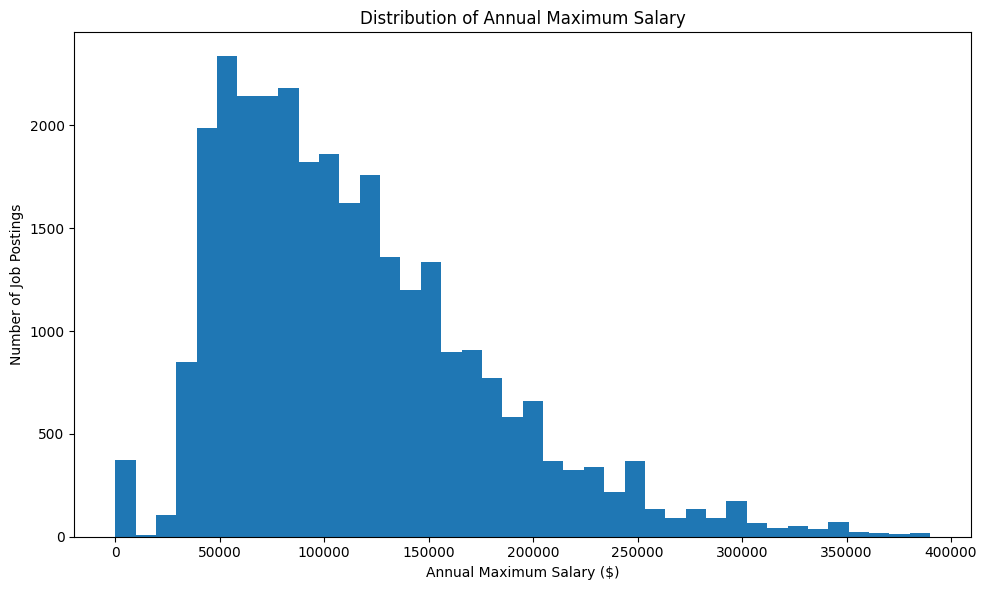

99th percentile salary: 390000.0


In [195]:
import matplotlib.pyplot as plt

salary_99 = clean_salary_data["annual_max_salary"].quantile(0.99)

plot_salary = clean_salary_data[
    clean_salary_data["annual_max_salary"] <= salary_99
]

plt.figure(figsize=(10, 6))

plt.hist(
    plot_salary["annual_max_salary"],
    bins=40
)

plt.title("Distribution of Annual Maximum Salary")
plt.xlabel("Annual Maximum Salary ($)")
plt.ylabel("Number of Job Postings")

plt.tight_layout()
plt.show()

print("99th percentile salary:", salary_99)

In [196]:

salary_99 = clean_salary_data["annual_max_salary"].quantile(0.99)

print("99th percentile salary:", salary_99)
reasonable_salary_data = clean_salary_data[
    (clean_salary_data["annual_max_salary"] > 0) &
    (clean_salary_data["annual_max_salary"] <= salary_99)
]
salary_by_title = (
    reasonable_salary_data
    .groupby("title")["annual_max_salary"]
    .agg(["count", "mean", "median"])
    .sort_values("median", ascending=False)
)

# Top 10
top_10_titles = salary_by_title.head(10)

print("Top 10 Highest-Paying Job Titles")
print(top_10_titles)

99th percentile salary: 390000.0
Top 10 Highest-Paying Job Titles
                                                    count      mean    median
title                                                                        
Consumer Products Associate - Mid-Level                 2  390000.0  390000.0
Corporate Oil & Gas Attorney                            1  390000.0  390000.0
Fund Formation Attorney                                 1  390000.0  390000.0
Sr. Linux Kernel Software Engineer - Seattle            1  389500.0  389500.0
Senior Director, Solutions & Alliances Product ...      1  387000.0  387000.0
Dir, Solutions Consulting                               1  385800.0  385800.0
Account Executive, Strategic Retail                     4  385000.0  385000.0
Live Streaming Content Creator                          1  384000.0  384000.0
Director, Product Management for File, Object, ...      1  383500.0  383500.0
Medical Director, Oncology Asset Development Team       1  383300.0  383300.

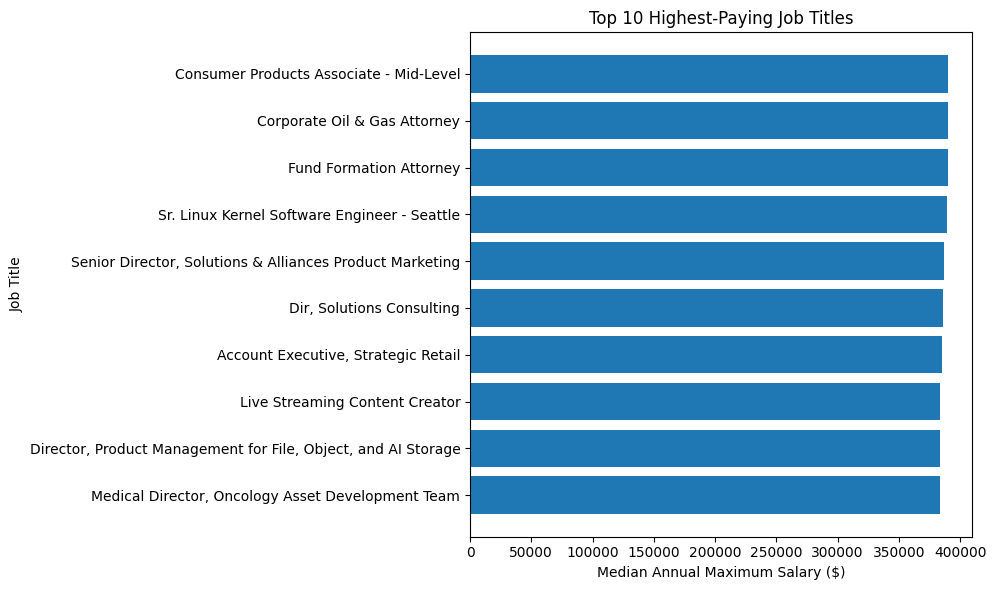

In [197]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.barh(
    top_10_titles.index[::-1],
    top_10_titles["median"][::-1]
)

plt.title("Top 10 Highest-Paying Job Titles")
plt.xlabel("Median Annual Maximum Salary ($)")
plt.ylabel("Job Title")

plt.tight_layout()
plt.show()

The analysis identifies the top 10 job titles with the highest median annual maximum salaries. These roles are mainly specialized, senior, technical, legal, consulting, and medical positions. The highest median salary in the filtered dataset is approximately $390,000.

In [198]:

salary_by_experience = (
    clean_salary_data[
        (clean_salary_data["annual_max_salary"] > 0) &
        (clean_salary_data["annual_max_salary"] <= salary_99)
    ]
    .groupby("formatted_experience_level")["annual_max_salary"]
    .agg(["count", "mean", "median"])
    .sort_values("median", ascending=False)
)

print("Salary by Experience Level")
print(salary_by_experience)

Salary by Experience Level
                            count           mean    median
formatted_experience_level                                
Executive                     325  209226.643631  213000.0
Director                     1171  193010.484799  187200.0
Mid-Senior level            11348  130225.268269  124800.0
Associate                    3458   93335.872695   83200.0
Entry level                  6344   79978.628775   65000.0
Internship                    237   65115.717131   59800.0


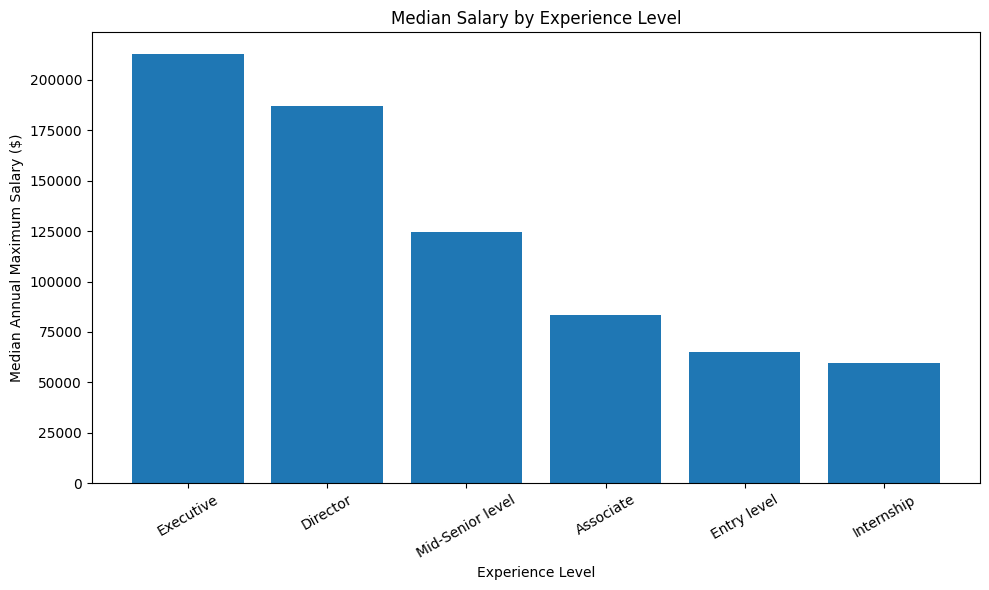

In [199]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.bar(
    salary_by_experience.index,
    salary_by_experience["median"]
)

plt.title("Median Salary by Experience Level")
plt.xlabel("Experience Level")
plt.ylabel("Median Annual Maximum Salary ($)")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

The analysis shows a clear relationship between experience level and salary. Executive-level positions have the highest median annual maximum salary at approximately $213,000, followed by Director ($187,200) and Mid-Senior-level ($124,800) positions.

Entry-level ($65,000) and Internship ($59,900) positions have the lowest median salaries. This indicates that higher experience and seniority are generally associated with higher salary levels.

In [200]:
salary_by_work_type = (
    clean_salary_data[
        (clean_salary_data["annual_max_salary"] > 0) &
        (clean_salary_data["annual_max_salary"] <= salary_99)
    ]
    .groupby("work_type")["annual_max_salary"]
    .agg(["count", "mean", "median"])
    .sort_values("median", ascending=False)
)

print("Salary by Work Type")
print(salary_by_work_type)

Salary by Work Type
            count           mean    median
work_type                                 
CONTRACT     3222  109585.714817  104000.0
FULL_TIME   24275  117965.449347  104000.0
OTHER          88  102422.133068   89440.0
TEMPORARY     279   87728.045878   72800.0
INTERNSHIP    139   67870.069784   58240.0
PART_TIME    1492   70776.213479   52000.0
VOLUNTEER       1   44850.000000   44850.0


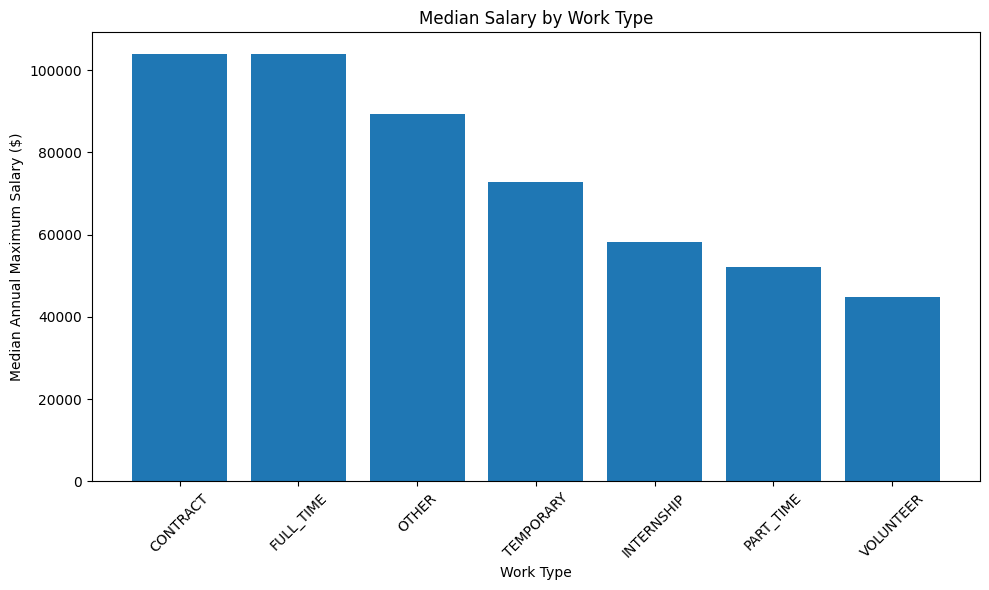

In [201]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.bar(
    salary_by_work_type.index,
    salary_by_work_type["median"]
)

plt.title("Median Salary by Work Type")
plt.xlabel("Work Type")
plt.ylabel("Median Annual Maximum Salary ($)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Contract and full-time positions have the highest median annual maximum salary at approximately $104,000. Other and temporary positions have moderate salary levels, while internship, part-time, and volunteer positions have lower median salaries. This suggests that full-time and contract employment generally offer better salary opportunities than temporary or entry-level work arrangements.

In [202]:
salary_by_location = (
    clean_salary_data[
        (clean_salary_data["annual_max_salary"] > 0) &
        (clean_salary_data["annual_max_salary"] <= salary_99)
    ]
    .groupby("location")["annual_max_salary"]
    .agg(["count", "mean", "median"])
    .sort_values("median", ascending=False)
)

top_10_locations = salary_by_location.head(10)

print("Top 10 Highest-Paying Locations")
print(top_10_locations)

Top 10 Highest-Paying Locations
                         count           mean    median
location                                               
Oconomowoc, WI               1  360000.000000  360000.0
Highland, IL                 1  350000.000000  350000.0
East Rockaway, NY            1  350000.000000  350000.0
Bibb County, GA              1  350000.000000  350000.0
North Wales, PA              3  278766.666667  347500.0
Greater Burlington Area      1  343320.000000  343320.0
East Garden City, NY         1  312700.000000  312700.0
Walpole, MA                  1  308847.000000  308847.0
Easton, MD                   1  307413.000000  307413.0
Galesburg, IL                1  300000.000000  300000.0


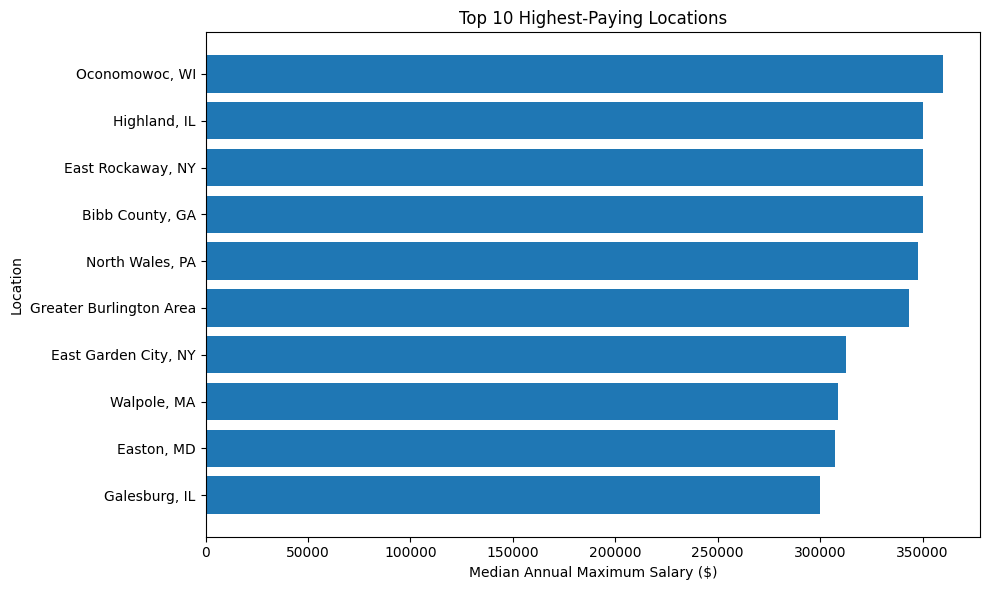

In [203]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.barh(
    top_10_locations.index[::-1],
    top_10_locations["median"][::-1]
)

plt.title("Top 10 Highest-Paying Locations")
plt.xlabel("Median Annual Maximum Salary ($)")
plt.ylabel("Location")

plt.tight_layout()
plt.show()

The analysis shows that Oconomowoc, WI has the highest median annual maximum salary at approximately $360,000, followed by Highland, IL, East Rockaway, NY, and Bibb County, GA at around $350,000. However, most of these locations have only one job posting, so the results may be influenced by individual high-paying positions. Therefore, these values should be interpreted as job-posting-level observations rather than typical salaries for the entire location.

In [204]:
jobs.columns

Index(['job_id', 'company_name', 'title', 'description', 'max_salary',
       'pay_period', 'location', 'company_id', 'views', 'med_salary',
       'min_salary', 'formatted_work_type', 'applies', 'original_listed_time',
       'remote_allowed', 'job_posting_url', 'application_url',
       'application_type', 'expiry', 'closed_time',
       'formatted_experience_level', 'skills_desc', 'listed_time',
       'posting_domain', 'sponsored', 'work_type', 'currency',
       'compensation_type', 'normalized_salary', 'zip_code', 'fips'],
      dtype='object')

In [205]:
jobs.columns.tolist()

['job_id',
 'company_name',
 'title',
 'description',
 'max_salary',
 'pay_period',
 'location',
 'company_id',
 'views',
 'med_salary',
 'min_salary',
 'formatted_work_type',
 'applies',
 'original_listed_time',
 'remote_allowed',
 'job_posting_url',
 'application_url',
 'application_type',
 'expiry',
 'closed_time',
 'formatted_experience_level',
 'skills_desc',
 'listed_time',
 'posting_domain',
 'sponsored',
 'work_type',
 'currency',
 'compensation_type',
 'normalized_salary',
 'zip_code',
 'fips']

In [206]:
jobs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123849 entries, 0 to 123848
Data columns (total 31 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   job_id                      123849 non-null  int64  
 1   company_name                122130 non-null  object 
 2   title                       123849 non-null  object 
 3   description                 123842 non-null  object 
 4   max_salary                  29793 non-null   float64
 5   pay_period                  36073 non-null   object 
 6   location                    123849 non-null  object 
 7   company_id                  122132 non-null  float64
 8   views                       122160 non-null  float64
 9   med_salary                  6280 non-null    float64
 10  min_salary                  29793 non-null   float64
 11  formatted_work_type         123849 non-null  object 
 12  applies                     23320 non-null   float64
 13  original_liste

In [207]:
missing_values = jobs.isnull().sum()
print(missing_values)

job_id                             0
company_name                    1719
title                              0
description                        7
max_salary                     94056
pay_period                     87776
location                           0
company_id                      1717
views                           1689
med_salary                    117569
min_salary                     94056
formatted_work_type                0
applies                       100529
original_listed_time               0
remote_allowed                108603
job_posting_url                    0
application_url                36665
application_type                   0
expiry                             0
closed_time                   122776
formatted_experience_level     29409
skills_desc                   121410
listed_time                        0
posting_domain                 39968
sponsored                          0
work_type                          0
currency                       87776
c

In [208]:
missing_percent = (jobs.isnull().sum()/len(jobs))*100
print(missing_percent.sort_values(ascending=False))

closed_time                   99.133622
skills_desc                   98.030666
med_salary                    94.929309
remote_allowed                87.689848
applies                       81.170619
min_salary                    75.944093
max_salary                    75.944093
currency                      70.873402
compensation_type             70.873402
pay_period                    70.873402
normalized_salary             70.873402
posting_domain                32.271556
application_url               29.604599
formatted_experience_level    23.745852
fips                          22.135827
zip_code                      16.852780
company_name                   1.387981
company_id                     1.386366
views                          1.363757
description                    0.005652
job_id                         0.000000
title                          0.000000
location                       0.000000
original_listed_time           0.000000
formatted_work_type            0.000000


In [209]:
analysis_data = jobs[
    [
        "job_id",
        "company_name",
        "title",
        "location",
        "max_salary",
        "min_salary",
        "pay_period",
        "formatted_work_type",
        "formatted_experience_level",
        "views",
        "remote_allowed",
        "work_type",
        "currency"

    ]
].copy()
print("Analysis dataset created!")
print("Rows:",len(analysis_data))
print("columns:",len(analysis_data.columns))

Analysis dataset created!
Rows: 123849
columns: 13


In [210]:
analysis_data.head()

,job_id,company_name,title,location,max_salary,min_salary,pay_period,formatted_work_type,formatted_experience_level,views,remote_allowed,work_type,currency
0,921716,Corcoran Sawyer Smith,Marketing Coordinator,"Princeton, NJ",20.0,17.0,HOURLY,Full-time,NaN,20.0,NaN,FULL_TIME,USD
1,1829192,NaN,Mental Health Therapist/Counselor,"Fort Collins, CO",50.0,30.0,HOURLY,Full-time,NaN,1.0,NaN,FULL_TIME,USD
2,10998357,The National Exemplar,Assitant Restaurant Manager,"Cincinnati, OH",65000.0,45000.0,YEARLY,Full-time,NaN,8.0,NaN,FULL_TIME,USD
3,23221523,"Abrams Fensterman, LLP",Senior Elder Law / Trusts and Estates Associat...,"New Hyde Park, NY",175000.0,140000.0,YEARLY,Full-time,NaN,16.0,NaN,FULL_TIME,USD
4,35982263,NaN,Service Technician,"Burlington, IA",80000.0,60000.0,YEARLY,Full-time,NaN,3.0,NaN,FULL_TIME,USD


In [211]:
analysis_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123849 entries, 0 to 123848
Data columns (total 13 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   job_id                      123849 non-null  int64  
 1   company_name                122130 non-null  object 
 2   title                       123849 non-null  object 
 3   location                    123849 non-null  object 
 4   max_salary                  29793 non-null   float64
 5   min_salary                  29793 non-null   float64
 6   pay_period                  36073 non-null   object 
 7   formatted_work_type         123849 non-null  object 
 8   formatted_experience_level  94440 non-null   object 
 9   views                       122160 non-null  float64
 10  remote_allowed              15246 non-null   float64
 11  work_type                   123849 non-null  object 
 12  currency                    36073 non-null   object 
dtypes: float64(4),

In [212]:
print("Duplicate rows:",analysis_data.duplicated().sum())
print("Duplicate job IDs:",analysis_data["job_id"].duplicated().sum())

Duplicate rows: 0
Duplicate job IDs: 0


In [213]:
analysis_data[analysis_data["job_id"].duplicated(keep=False)].head(10)

,job_id,company_name,title,location,max_salary,min_salary,pay_period,formatted_work_type,formatted_experience_level,views,remote_allowed,work_type,currency


In [214]:
missing_percent = (analysis_data.isnull().sum() / len(analysis_data))*100
missing_summery = pd.DataFrame({
   "missing_count": analysis_data.isnull().sum(),
   "missing_percent": missing_percent
})
print(missing_summery.sort_values("missing_percent", ascending=False))

                            missing_count  missing_percent
remote_allowed                     108603        87.689848
min_salary                          94056        75.944093
max_salary                          94056        75.944093
pay_period                          87776        70.873402
currency                            87776        70.873402
formatted_experience_level          29409        23.745852
company_name                         1719         1.387981
views                                1689         1.363757
job_id                                  0         0.000000
location                                0         0.000000
title                                   0         0.000000
formatted_work_type                     0         0.000000
work_type                               0         0.000000


In [215]:
analysis_data = analysis_data.drop(columns=["remote_allowed"])

print("Columns after cleaning:", len(analysis_data.columns))

Columns after cleaning: 12


In [216]:
analysis_data["company_name"] = analysis_data["company_name"].fillna("Unknown")

analysis_data["formatted_experience_level"] = (
    analysis_data["formatted_experience_level"].fillna("Unknown")
)

print("Missing values filled successfully")

Missing values filled successfully


In [217]:
print(analysis_data[[
    "company_name",
    "formatted_experience_level"
]].isnull().sum())

company_name                  0
formatted_experience_level    0
dtype: int64


In [218]:
print("Salary information:")
print("Rows with salary:", analysis_data["max_salary"].notna().sum())
print("Rows without salary:", analysis_data["max_salary"].isna().sum())

print("\nPay period:")
print(analysis_data["pay_period"].value_counts(dropna=False))

Salary information:
Rows with salary: 29793
Rows without salary: 94056

Pay period:
pay_period
NaN         87776
YEARLY      20628
HOURLY      14741
MONTHLY       518
WEEKLY        177
BIWEEKLY        9
Name: count, dtype: int64


In [219]:
salary_data = analysis_data[
    analysis_data["max_salary"].notna()
].copy()

print("Salary dataset created!")
print("Rows:", len(salary_data))
print("Columns:", len(salary_data.columns))

Salary dataset created!
Rows: 29793
Columns: 12


In [220]:
salary_data["annual_max_salary"] = salary_data.apply(
    lambda row:
        row["max_salary"] * 2080 if row["pay_period"] == "HOURLY"
        else row["max_salary"] * 52 if row["pay_period"] == "WEEKLY"
        else row["max_salary"] * 26 if row["pay_period"] == "BIWEEKLY"
        else row["max_salary"] * 12 if row["pay_period"] == "MONTHLY"
        else row["max_salary"] if row["pay_period"] == "YEARLY"
        else None,
    axis=1
)

print("Annual salary column created successfully!")
print(salary_data[["max_salary", "pay_period", "annual_max_salary"]].head(10))

Annual salary column created successfully!
    max_salary pay_period  annual_max_salary
0         20.0     HOURLY            41600.0
1         50.0     HOURLY           104000.0
2      65000.0     YEARLY            65000.0
3     175000.0     YEARLY           175000.0
4      80000.0     YEARLY            80000.0
5         20.0     HOURLY            41600.0
6     300000.0     YEARLY           300000.0
7     120000.0     YEARLY           120000.0
17        19.0     HOURLY            39520.0
28        24.0     HOURLY            49920.0


In [221]:
print("Annual Salary Statistics")
print(salary_data["annual_max_salary"].describe())

Annual Salary Statistics
count    2.979300e+04
mean     2.639483e+05
std      6.096351e+06
min      1.000000e+00
25%      6.572800e+04
50%      1.010000e+05
75%      1.500000e+05
max      5.720000e+08
Name: annual_max_salary, dtype: float64


In [222]:
salary_data[[
    "title",
    "location",
    "min_salary",
    "max_salary",
    "pay_period",
    "currency"
]].head(10)

,title,location,min_salary,max_salary,pay_period,currency
0,Marketing Coordinator,"Princeton, NJ",17.0,20.0,HOURLY,USD
1,Mental Health Therapist/Counselor,"Fort Collins, CO",30.0,50.0,HOURLY,USD
2,Assitant Restaurant Manager,"Cincinnati, OH",45000.0,65000.0,YEARLY,USD
3,Senior Elder Law / Trusts and Estates Associat...,"New Hyde Park, NY",140000.0,175000.0,YEARLY,USD
4,Service Technician,"Burlington, IA",60000.0,80000.0,YEARLY,USD
5,Economic Development and Planning Intern,"Raleigh, NC",14.0,20.0,HOURLY,USD
6,Producer,United States,60000.0,300000.0,YEARLY,USD
7,Building Engineer,"San Francisco, CA",90000.0,120000.0,YEARLY,USD
17,Customer Service / Reservationist,"Providence, RI",18.0,19.0,HOURLY,USD
28,General Laborer,"Erie, PA",18.0,24.0,HOURLY,USD


In [223]:
salary_data["annual_min_salary"] = salary_data["min_salary"]
salary_data["annual_max_salary"] = salary_data["max_salary"]

# Convert hourly salaries to yearly
hourly = salary_data["pay_period"] == "HOURLY"

salary_data.loc[hourly, "annual_min_salary"] *= 2080
salary_data.loc[hourly, "annual_max_salary"] *= 2080

# Convert monthly salaries to yearly
monthly = salary_data["pay_period"] == "MONTHLY"

salary_data.loc[monthly, "annual_min_salary"] *= 12
salary_data.loc[monthly, "annual_max_salary"] *= 12

# Convert weekly salaries to yearly
weekly = salary_data["pay_period"] == "WEEKLY"

salary_data.loc[weekly, "annual_min_salary"] *= 52
salary_data.loc[weekly, "annual_max_salary"] *= 52

# Convert biweekly salaries to yearly
biweekly = salary_data["pay_period"] == "BIWEEKLY"

salary_data.loc[biweekly, "annual_min_salary"] *= 26

salary_data.loc[biweekly, "annual_max_salary"] *= 26

print("Salary conversion completed!")

Salary conversion completed!


In [224]:
salary_data[[
    "title",
    "min_salary",
    "max_salary",
    "pay_period",
    "annual_min_salary",
    "annual_max_salary"
]].head(10)

,title,min_salary,max_salary,pay_period,annual_min_salary,annual_max_salary
0,Marketing Coordinator,17.0,20.0,HOURLY,35360.0,41600.0
1,Mental Health Therapist/Counselor,30.0,50.0,HOURLY,62400.0,104000.0
2,Assitant Restaurant Manager,45000.0,65000.0,YEARLY,45000.0,65000.0
3,Senior Elder Law / Trusts and Estates Associat...,140000.0,175000.0,YEARLY,140000.0,175000.0
4,Service Technician,60000.0,80000.0,YEARLY,60000.0,80000.0
5,Economic Development and Planning Intern,14.0,20.0,HOURLY,29120.0,41600.0
6,Producer,60000.0,300000.0,YEARLY,60000.0,300000.0
7,Building Engineer,90000.0,120000.0,YEARLY,90000.0,120000.0
17,Customer Service / Reservationist,18.0,19.0,HOURLY,37440.0,39520.0
28,General Laborer,18.0,24.0,HOURLY,37440.0,49920.0


In [225]:
print("Annual Salary Statistics")
print(salary_data["annual_max_salary"].describe())

Annual Salary Statistics
count    2.979300e+04
mean     2.639483e+05
std      6.096351e+06
min      1.000000e+00
25%      6.572800e+04
50%      1.010000e+05
75%      1.500000e+05
max      5.720000e+08
Name: annual_max_salary, dtype: float64


In [226]:
print("Average minimum salary:",salary_data["annual_min_salary"].mean())
print("Average maximum salary:",salary_data["annual_max_salary"].mean())

Average minimum salary: 206153.93129594202
Average maximum salary: 263948.2868757762


In [227]:
salary_data.sort_values(
    "annual_max_salary",
    ascending=False
)[[
    "title",
    "location",
    "annual_min_salary",
    "annual_max_salary"
]].head(10)

,title,location,annual_min_salary,annual_max_salary
9237,Intellectual Property Associate (246215),"Dallas, TX",499200000.0,572000000.0
98888,"Case Manager RN, Pedi Rheumatology","Roseville, CA",315952000.0,408865600.0
89082,Cloud Domain Architect,"Houston, TX",260000000.0,312000000.0
13614,Cloud Domain Architect,"Houston, TX",260000000.0,312000000.0
60038,Billing Supervisor (246521),"Westwood, CA",260000000.0,260000000.0
102481,Manager - Clinical Applications Support - Anci...,"Lakeland, FL",204811360.0,256035520.0
71845,Sharepoint Developer,"Springfield, Illinois Metropolitan Area",208000000.0,249600000.0
72585,Trial Paralegal - Hybrid in OC or LA!,"Los Angeles County, CA",166400000.0,208000000.0
17646,DCS Technician,"Charleston, SC",145600000.0,166400000.0
40781,Sales Representative- Entry Level ($50k base +...,"Bloomington, MN",104000000.0,145600000.0


In [228]:
salary_99 = salary_data["annual_max_salary"].quantile(0.99)

clean_salary_data = salary_data[
    salary_data["annual_max_salary"] <= salary_99
].copy()

print("99th percentile salary:", salary_99)
print("Original rows:", len(salary_data))
print("Clean rows:", len(clean_salary_data))
print("Maximum salary after cleaning:",
      clean_salary_data["annual_max_salary"].max())

99th percentile salary: 390000.0
Original rows: 29793
Clean rows: 29496
Maximum salary after cleaning: 390000.0


In [229]:
salary_by_experience = (
    clean_salary_data[
        clean_salary_data["annual_max_salary"] > 0
    ]
    .groupby("formatted_experience_level")["annual_max_salary"]
    .agg(["count", "mean", "median"])
    .sort_values("median", ascending=False)
)

print("Salary by Experience Level")
print(salary_by_experience)

Salary by Experience Level
                            count           mean    median
formatted_experience_level                                
Executive                     325  209226.643631  213000.0
Director                     1171  193010.484799  187200.0
Mid-Senior level            11348  130225.268269  124800.0
Unknown                      6613  113092.401916   96200.0
Associate                    3458   93335.872695   83200.0
Entry level                  6344   79978.628775   65000.0
Internship                    237   65115.717131   59800.0


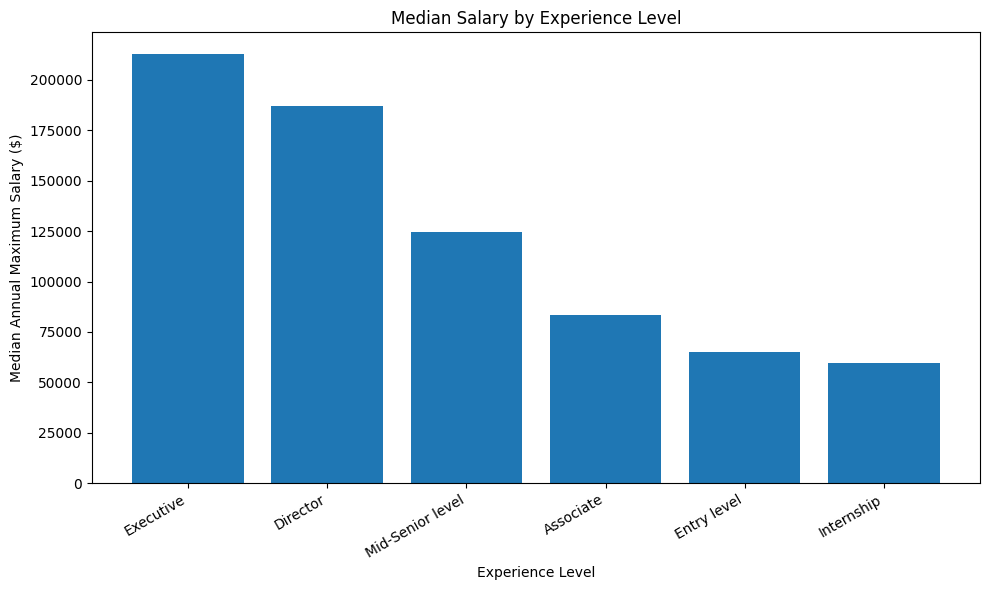

In [230]:
import matplotlib.pyplot as plt

plot_data = salary_by_experience.drop(index="Unknown", errors="ignore")

plt.figure(figsize=(10, 6))

plt.bar(
    plot_data.index,
    plot_data["median"]
)

plt.title("Median Salary by Experience Level")
plt.xlabel("Experience Level")
plt.ylabel("Median Annual Maximum Salary ($)")
plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.show()

 Salary by Experience Level

The analysis shows that salary increases significantly with experience level. Executive positions have the highest median annual maximum salary of approximately $213,000, followed by Director positions at $187,200.

Mid-Senior level positions have a median salary of about $124,800, while Associate and Entry-level positions have lower median salaries of approximately $83,200 and $65,000 respectively. Internship positions have the lowest median salary at approximately $59,800.

Overall, higher experience and seniority are generally associated with higher salary opportunities.

In [231]:
salary_by_title = (
    clean_salary_data[
        (clean_salary_data["annual_max_salary"] > 0)
    ]
    .groupby("title")["annual_max_salary"]
    .agg(["count", "mean", "median"])
    .sort_values("median", ascending=False)
)

top_10_titles = salary_by_title.head(10)

print("Top 10 Highest-Paying Job Titles")
print(top_10_titles)

Top 10 Highest-Paying Job Titles
                                                    count      mean    median
title                                                                        
Consumer Products Associate - Mid-Level                 2  390000.0  390000.0
Corporate Oil & Gas Attorney                            1  390000.0  390000.0
Fund Formation Attorney                                 1  390000.0  390000.0
Sr. Linux Kernel Software Engineer - Seattle            1  389500.0  389500.0
Senior Director, Solutions & Alliances Product ...      1  387000.0  387000.0
Dir, Solutions Consulting                               1  385800.0  385800.0
Account Executive, Strategic Retail                     4  385000.0  385000.0
Live Streaming Content Creator                          1  384000.0  384000.0
Director, Product Management for File, Object, ...      1  383500.0  383500.0
Medical Director, Oncology Asset Development Team       1  383300.0  383300.0


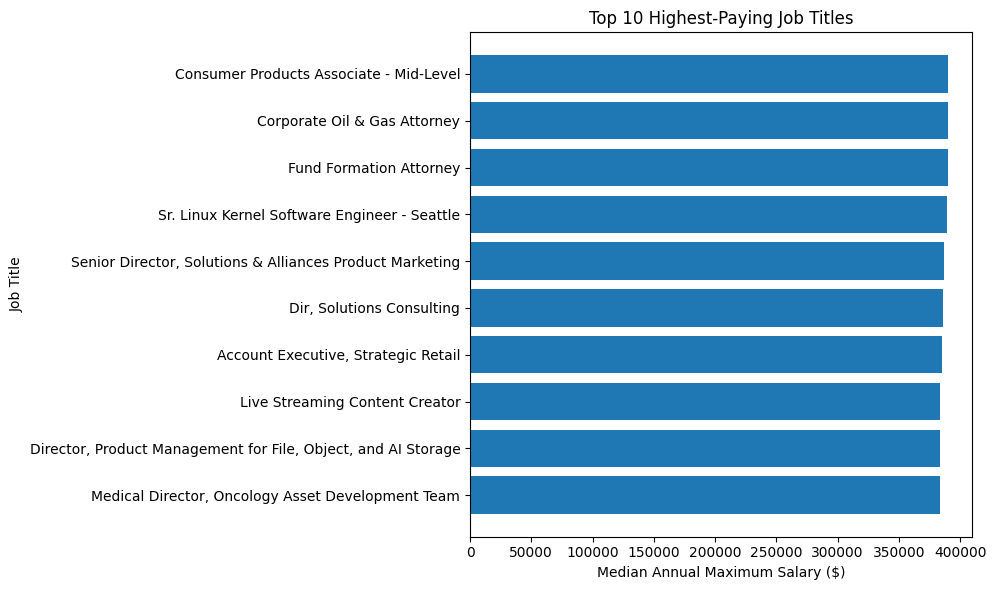

In [232]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_10_titles.index[::-1],
    top_10_titles["median"][::-1]
)

plt.title("Top 10 Highest-Paying Job Titles")
plt.xlabel("Median Annual Maximum Salary ($)")
plt.ylabel("Job Title")

plt.tight_layout()
plt.show()

 Salary by Job Title

The analysis shows that the highest-paying job titles have median annual maximum salaries close to $390,000. Consumer Products Associate - Mid-Level, Corporate Oil & Gas Attorney, and Fund Formation Attorney are among the highest-paying positions.

The results also include highly specialized technical and management roles such as Senior Linux Kernel Software Engineer, Senior Director, and Medical Director.

Overall, specialized professional, technical, legal, and senior management positions tend to offer higher salary opportunities.

In [233]:

remote_salary_data = jobs[
    ["max_salary", "pay_period", "remote_allowed", "currency"]
].copy()
remote_salary_data = remote_salary_data[
    remote_salary_data["max_salary"].notna() &
    remote_salary_data["remote_allowed"].notna()
].copy()
remote_salary_data = remote_salary_data[
    remote_salary_data["currency"] == "USD"
].copy()
remote_salary_data["annual_max_salary"] = remote_salary_data.apply(
    lambda row:
        row["max_salary"] * 2080 if row["pay_period"] == "HOURLY"
        else row["max_salary"] * 52 if row["pay_period"] == "WEEKLY"
        else row["max_salary"] * 26 if row["pay_period"] == "BIWEEKLY"
        else row["max_salary"] * 12 if row["pay_period"] == "MONTHLY"
        else row["max_salary"]
        if row["pay_period"] == "YEARLY"
        else None,
    axis=1
)

remote_salary_data = remote_salary_data[
    remote_salary_data["annual_max_salary"] > 0
]
remote_salary = (
    remote_salary_data
    .groupby("remote_allowed")["annual_max_salary"]
    .agg(["count", "mean", "median"])
)

print("Remote Work vs Salary")
print(remote_salary)

Remote Work vs Salary
                count           mean    median
remote_allowed                                
1.0              4316  291514.921661  130000.0


### Remote Work Availability

The analysis shows that 4,316 job postings have information indicating that remote work is allowed after filtering for valid USD salary data.

However, most records have missing values for the remote-work field, so a reliable comparison between remote and non-remote salaries cannot be made.

Therefore, remote-work availability is treated as a descriptive finding rather than a salary comparison.

# Final Project Summary

## Conclusion

This project analyzed job salary data to understand salary patterns across different experience levels, job titles, and work arrangements.

The analysis showed that salary generally increases with experience and seniority. Executive and Director-level positions had the highest median annual maximum salaries, while Internship and Entry-level positions had lower salary levels.

The analysis also identified several highly paid specialized job titles, with some positions having median annual maximum salaries close to $390,000.

Salary data was standardized by converting hourly, weekly, biweekly, and monthly salaries into annual salaries. Extreme salary values were handled using the 99th percentile to reduce the effect of outliers.

The remote-work analysis found 4,316 job postings indicating that remote work was allowed after filtering for valid salary data. However, because many records have missing remote-work information, a reliable comparison between remote and non-remote salaries could not be made.

Overall, the analysis demonstrates that experience level, job specialization, and seniority are important factors associated with higher salary opportunities.

In [234]:
print("minimum annual salary:",salary_data["annual_min_salary"].min())
print("maximin annual salary:",salary_data["annual_max_salary"].max())

minimum annual salary: 1.0
maximin annual salary: 572000000.0


In [235]:
salary_data[
    salary_data["annual_min_salary"] <=1
][[
    "title",
    "min_salary",
    "max_salary",
    "pay_period",
    "annual_min_salary",
    "annual_max_salary"
]].head(20)

,title,min_salary,max_salary,pay_period,annual_min_salary,annual_max_salary
125,"Director, Investment Sales",1.0,40000.0,YEARLY,1.0,40000.0
191,Sales Development Representative,1.0,130813.0,YEARLY,1.0,130813.0
10978,Regional Sales Manager,1.0,2.0,YEARLY,1.0,2.0
26910,ACCOUNT DIRECTOR SENIOR-ENTERPRISE 1,1.0,1.0,YEARLY,1.0,1.0
32200,Financial Services Professional,1.0,100000.0,YEARLY,1.0,100000.0
33990,Fantasy Football Team Manager - Fantasy Turf W...,1.0,100000.0,YEARLY,1.0,100000.0
38033,Travel Agent Specializing in Disney Destinations,1.0,80000.0,YEARLY,1.0,80000.0
44482,Regional Life Insurance Sales Representative (...,1.0,150000.0,YEARLY,1.0,150000.0
48543,Equity Raiser,1.0,100000.0,YEARLY,1.0,100000.0
95631,Sr. Project Accountant,1.0,92500.0,YEARLY,1.0,92500.0


In [236]:
clean_salary_data = salary_data[
    (salary_data["annual_min_salary"] >=1000)&
    (salary_data["annual_max_salary"] >= salary_data["annual_min_salary"])&
    (salary_data["annual_max_salary"] <=1000000)
].copy()

print("Original salary rows:",len(salary_data))
print("Clean salary rows:", len(clean_salary_data))
print("Rows removed:", len(salary_data) - len(clean_salary_data))

Original salary rows: 29793
Clean salary rows: 29356
Rows removed: 437


In [237]:
print(
    "Minimum annual salary:",
    clean_salary_data["annual_min_salary"].min()
)
print(
    "Maximum annual salary:",
    clean_salary_data["annual_max_salary"].max()
)

Minimum annual salary: 1000.0
Maximum annual salary: 1000000.0


In [238]:
print("SALARY ANALYSIS")
print("=" * 40)

print("Average minimum salary:",
      clean_salary_data["annual_min_salary"].mean())
print("Average maximim salary:",
      clean_salary_data["annual_max_salary"].mean())
print("Median minimum salary:",
      clean_salary_data["annual_min_salary"].median())
print("Median maximum salary:",
      clean_salary_data["annual_max_salary"].median())
print("Minimun salary:",
      clean_salary_data["annual_min_salary"].min())
print("Maximum salary:",
      clean_salary_data["annual_max_salary"].max())

SALARY ANALYSIS
Average minimum salary: 87127.01594563291
Average maximim salary: 119149.0740799155
Median minimum salary: 76760.9
Median maximum salary: 103000.0
Minimun salary: 1000.0
Maximum salary: 1000000.0


In [239]:
highest_paying_jobs = clean_salary_data.sort_values(
    "annual_max_salary",
    ascending=False
)[[
    "title",
    "location",
    "pay_period",
    "annual_min_salary",
    "annual_max_salary"
]]
highest_paying_jobs.head(20)

,title,location,pay_period,annual_min_salary,annual_max_salary
73176,Litigation Partner,"California, United States",YEARLY,500000.0,1000000.0
73491,Intellectual Property Partner,"California, United States",YEARLY,500000.0,1000000.0
46926,Senior VP of Construction Operations,San Diego Metropolitan Area,YEARLY,1000.0,1000000.0
118302,Senior Software Engineer,"New York, United States",YEARLY,500000.0,1000000.0
117057,Quantitative Researcher,"New York, United States",YEARLY,650000.0,1000000.0
68582,Director of Construction,"Tuscaloosa, AL",YEARLY,1000.0,1000000.0
73461,Trust and Estates Partner,"California, United States",YEARLY,500000.0,1000000.0
73329,Labor & Employment Partner,"California, United States",YEARLY,500000.0,1000000.0
88823,Commercial Retail Leasing Broker,"New York, NY",YEARLY,100000.0,1000000.0
113069,Head of Front Office Technology,New York City Metropolitan Area,YEARLY,750000.0,1000000.0


<function matplotlib.pyplot.show(close=None, block=None)>

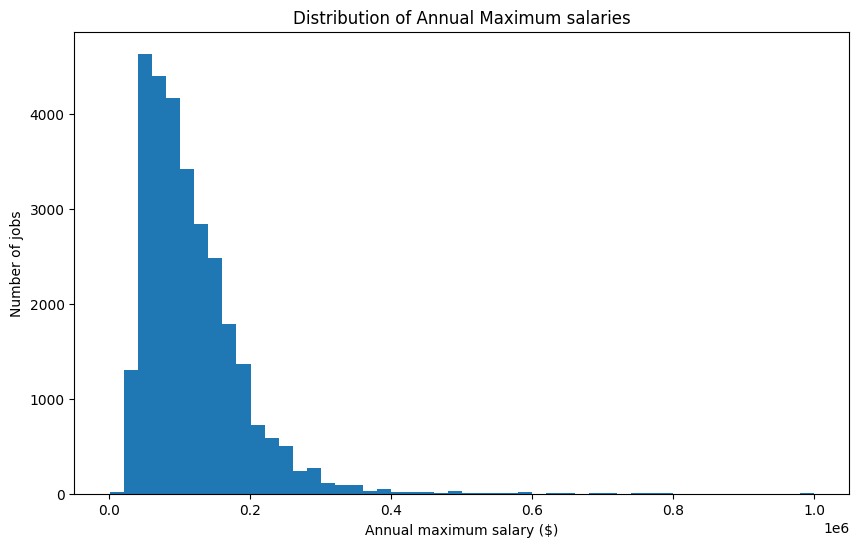

In [240]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10 , 6))
plt.hist(
    clean_salary_data["annual_max_salary"],
    bins=50
)

plt.xlabel("Annual maximum salary ($)")
plt.ylabel("Number of jobs")
plt.title("Distribution of Annual Maximum salaries")
plt.show

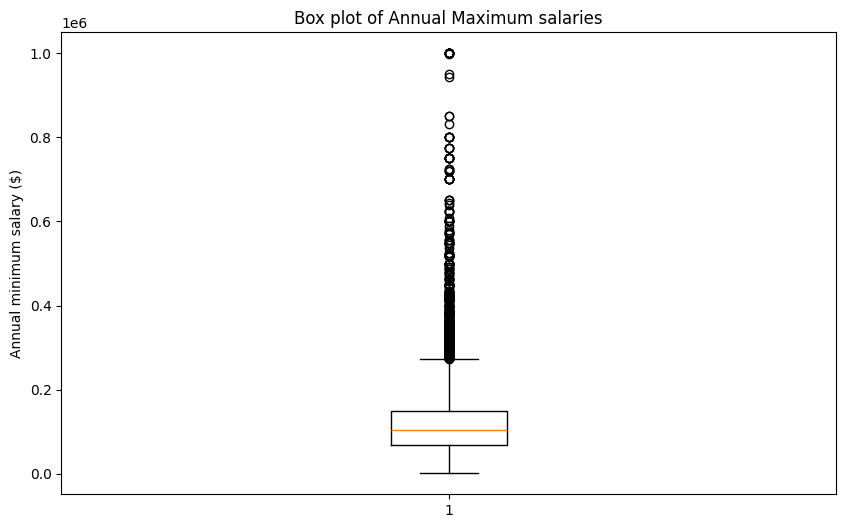

In [241]:
plt.figure(figsize=(10 , 6))

plt.boxplot(
    clean_salary_data["annual_max_salary"].dropna()
)

plt.ylabel("Annual minimum salary ($)")
plt.title("Box plot of Annual Maximum salaries")
plt.show()

In [242]:
salary_by_work_type = (
    clean_salary_data
    .groupby("formatted_work_type")["annual_max_salary"]
    .agg(["count", "mean", "median"])
    .sort_values("median", ascending=False)
)
salary_by_work_type

,count,mean,median
formatted_work_type,,,
Contract,3132,115095.867890,108160.0
Full-time,24261,122910.994689,105000.0
Other,89,120640.816966,89440.0
Temporary,273,93082.926007,72800.0
Internship,133,70479.439098,58240.0
Part-time,1467,74811.882345,52478.4
Volunteer,1,44850.000000,44850.0


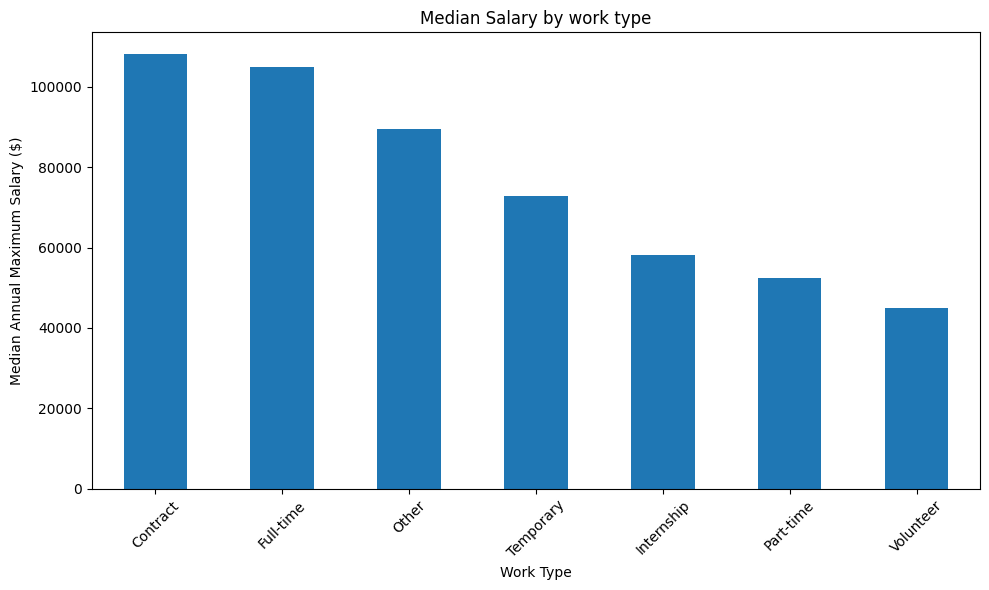

In [243]:
from matplotlib.figure import figaspect
plt.figure(figsize=(10 , 6))
salary_by_work_type["median"].plot(kind="bar")
plt.xlabel("Work Type")
plt.ylabel("Median Annual Maximum Salary ($)")
plt.title("Median Salary by work type")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [244]:
salary_by_experience = (
    clean_salary_data
    .groupby("formatted_experience_level")["annual_max_salary"]
    .agg(["count", "mean", "median"])
    .sort_values("median", ascending=False)
)
print(salary_by_experience)

                            count           mean    median
formatted_experience_level                                
Executive                     354  234188.153418  220000.0
Director                     1194  201701.812982  190000.0
Mid-Senior level            11293  135300.861639  125000.0
Unknown                      6601  119498.759885  100000.0
Associate                    3385   96366.043415   85000.0
Entry level                  6295   81907.907538   65500.0
Internship                    234   65950.291795   59852.0


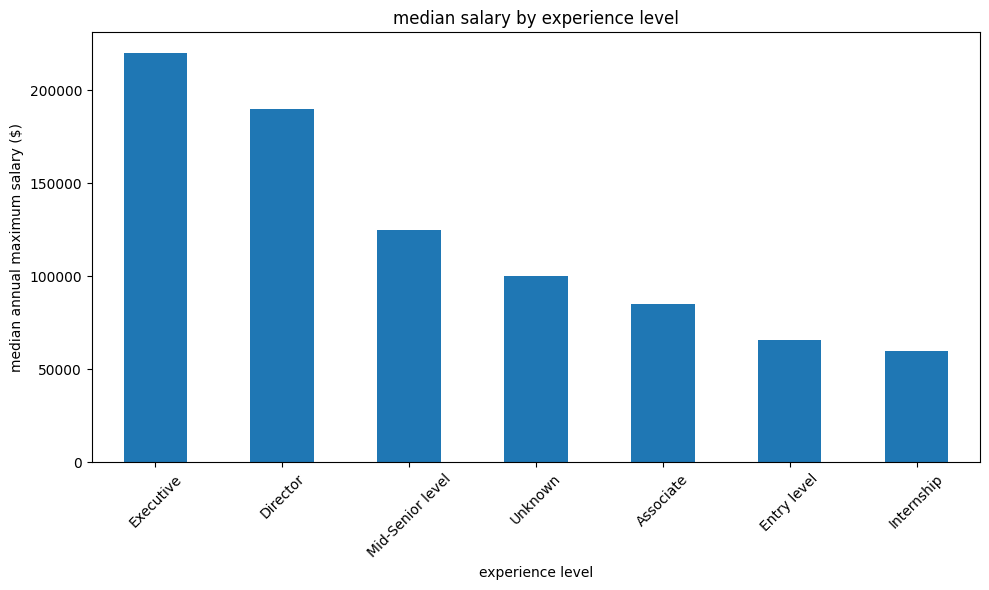

In [245]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10 , 6))
salary_by_experience["median"].plot(kind="bar")
plt.title("median salary by experience level")
plt.xlabel("experience level")
plt.ylabel("median annual maximum salary ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [246]:
salary_by_location = (
    clean_salary_data
    .groupby("location")["annual_max_salary"]
    .agg(["count", "mean", "median"])
)

salary_by_location = (
    salary_by_location[salary_by_location["count"] >=50]
    .sort_values("median", ascending=False)
)

print(salary_by_location.head(20))

                                 count           mean      median
location                                                         
Mountain View, CA                   53  196719.241509  197600.000
Sunnyvale, CA                       95  184041.911579  194000.000
San Jose, CA                       219  176591.446941  175000.000
Palo Alto, CA                       60  178747.256833  173028.705
San Francisco Bay Area             140  179948.355571  165000.000
Santa Clara, CA                     82  176290.614634  161120.000
San Francisco, CA                  363  168144.223774  156000.000
New York, United States            252  179982.877778  150000.000
Bellevue, WA                        90  163466.530333  150000.000
Illinois, United States             61  154259.350820  149760.000
Seattle, WA                        404  156283.154356  146800.000
Jersey City, NJ                     62  148021.796774  145600.000
McLean, VA                          65  153668.541538  145000.000
Arlington,

In [247]:
top_locations = salary_by_location.head(10)
print(top_locations)

                         count           mean      median
location                                                 
Mountain View, CA           53  196719.241509  197600.000
Sunnyvale, CA               95  184041.911579  194000.000
San Jose, CA               219  176591.446941  175000.000
Palo Alto, CA               60  178747.256833  173028.705
San Francisco Bay Area     140  179948.355571  165000.000
Santa Clara, CA             82  176290.614634  161120.000
San Francisco, CA          363  168144.223774  156000.000
New York, United States    252  179982.877778  150000.000
Bellevue, WA                90  163466.530333  150000.000
Illinois, United States     61  154259.350820  149760.000


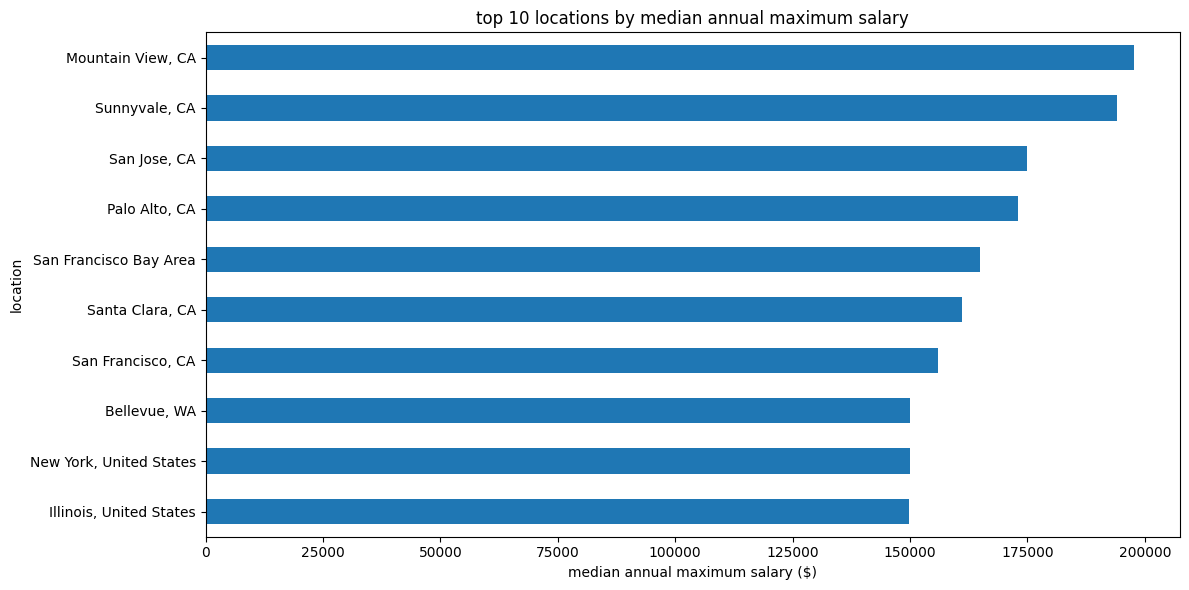

In [248]:
plt.figure(figsize=(12 , 6))
top_locations["median"].sort_values().plot(kind="barh")
plt.title("top 10 locations by median annual maximum salary")
plt.xlabel("median annual maximum salary ($)")
plt.ylabel("location")
plt.tight_layout()
plt.show()

In [249]:
salary_by_title = (
    clean_salary_data
    .groupby("title")["annual_max_salary"]
    .agg(["count", "mean", "median"])
    .sort_values("median",ascending=False)
)

salary_by_title = salary_by_title[salary_by_title["count"] >= 10]
print(salary_by_title.head(20))

                                  count           mean    median
title                                                           
Chief Financial Officer              19  276842.105263  275000.0
Head of Sales                        10  251000.000000  250000.0
Primary Care Physician               10  238500.000000  242500.0
Principal Software Engineer          10  228087.500000  238900.0
Licensed Mental Health Therapist     10  218608.000000  210080.0
Senior Product Manager               13  191552.692308  190000.0
Senior Site Reliability Engineer     10  201704.000000  189420.0
Seasonal Piecework Housekeeper       14  145005.714286  180960.0
Family Law Attorney                  10  187000.000000  180000.0
Litigation Attorney                  10  181000.000000  177500.0
Senior Software Engineer             57  206715.631579  175400.0
Litigation Associate                 16  191187.500000  172500.0
Senior Data Engineer                 12  172390.750000  172300.0
Senior Tax Manager       

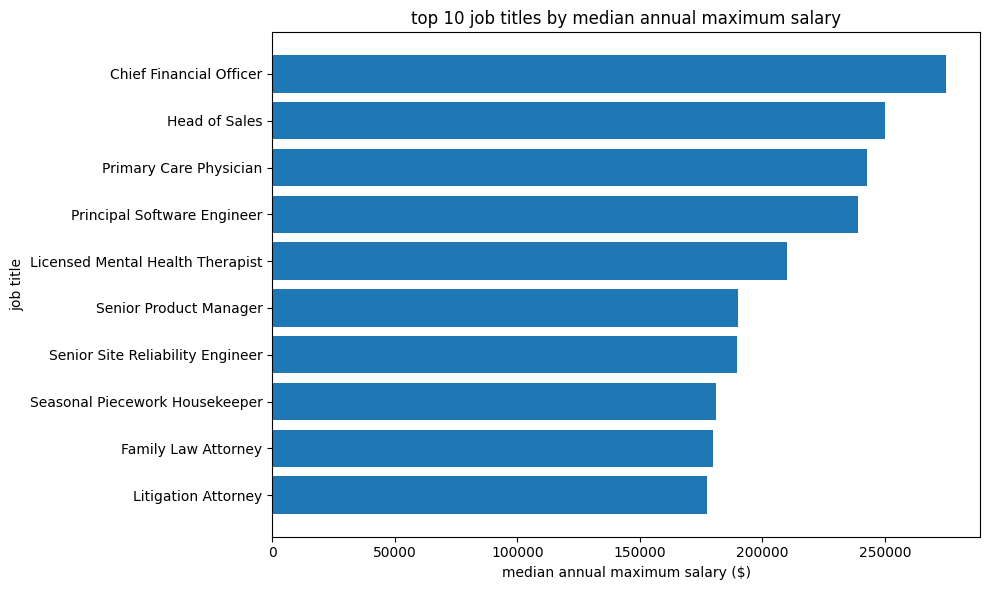

In [250]:
import matplotlib.pyplot as plt
top_10_titles = salary_by_title.head(10).sort_values("median")
plt.figure(figsize=(10 , 6))
plt.barh(
    top_10_titles.index,
    top_10_titles["median"]
)

plt.xlabel("median annual maximum salary ($)")
plt.ylabel("job title")
plt.title("top 10 job titles by median annual maximum salary")
plt.tight_layout()
plt.show()

In [251]:
print("TOP 10 HIGHRST-PAYING JOB TITLES")
print("=" * 50)

print(
    salary_by_title.head(10)[
        ["count", "mean", "median"]
    ]
)

TOP 10 HIGHRST-PAYING JOB TITLES
                                  count           mean    median
title                                                           
Chief Financial Officer              19  276842.105263  275000.0
Head of Sales                        10  251000.000000  250000.0
Primary Care Physician               10  238500.000000  242500.0
Principal Software Engineer          10  228087.500000  238900.0
Licensed Mental Health Therapist     10  218608.000000  210080.0
Senior Product Manager               13  191552.692308  190000.0
Senior Site Reliability Engineer     10  201704.000000  189420.0
Seasonal Piecework Housekeeper       14  145005.714286  180960.0
Family Law Attorney                  10  187000.000000  180000.0
Litigation Attorney                  10  181000.000000  177500.0


In [252]:


salary_exp_work = (
    clean_salary_data
    .groupby(["formatted_experience_level", "formatted_work_type"])
    ["annual_max_salary"]
    .median()
    .reset_index()
)

print(salary_exp_work)

   formatted_experience_level formatted_work_type  annual_max_salary
0                   Associate            Contract            78000.0
1                   Associate           Full-time            85000.0
2                   Associate          Internship            72800.0
3                   Associate           Part-time            53185.6
4                   Associate           Temporary            74880.0
5                    Director            Contract           183600.0
6                    Director           Full-time           190000.0
7                    Director          Internship           137460.0
8                    Director           Part-time           147100.0
9                    Director           Temporary           150000.0
10                Entry level            Contract            67800.0
11                Entry level           Full-time            70000.0
12                Entry level          Internship            72800.0
13                Entry level     

In [253]:
pivot_data = salary_exp_work.pivot(
    index="formatted_experience_level",
    columns="formatted_work_type",
    values="annual_max_salary"
)

print(pivot_data)

formatted_work_type         Contract  Full-time  Internship     Other  \
formatted_experience_level                                              
Associate                    78000.0    85000.0     72800.0       NaN   
Director                    183600.0   190000.0    137460.0       NaN   
Entry level                  67800.0    70000.0     72800.0   87220.0   
Executive                   162240.0   220000.0         NaN  159675.0   
Internship                   61360.0    62400.0     56160.0   70720.0   
Mid-Senior level            124800.0   125000.0    105000.0   89440.0   
Unknown                     110832.8   100000.0     52000.0   92640.0   

formatted_work_type         Part-time  Temporary  Volunteer  
formatted_experience_level                                   
Associate                     53185.6    74880.0        NaN  
Director                     147100.0   150000.0        NaN  
Entry level                   45240.0    51000.0    44850.0  
Executive                     89

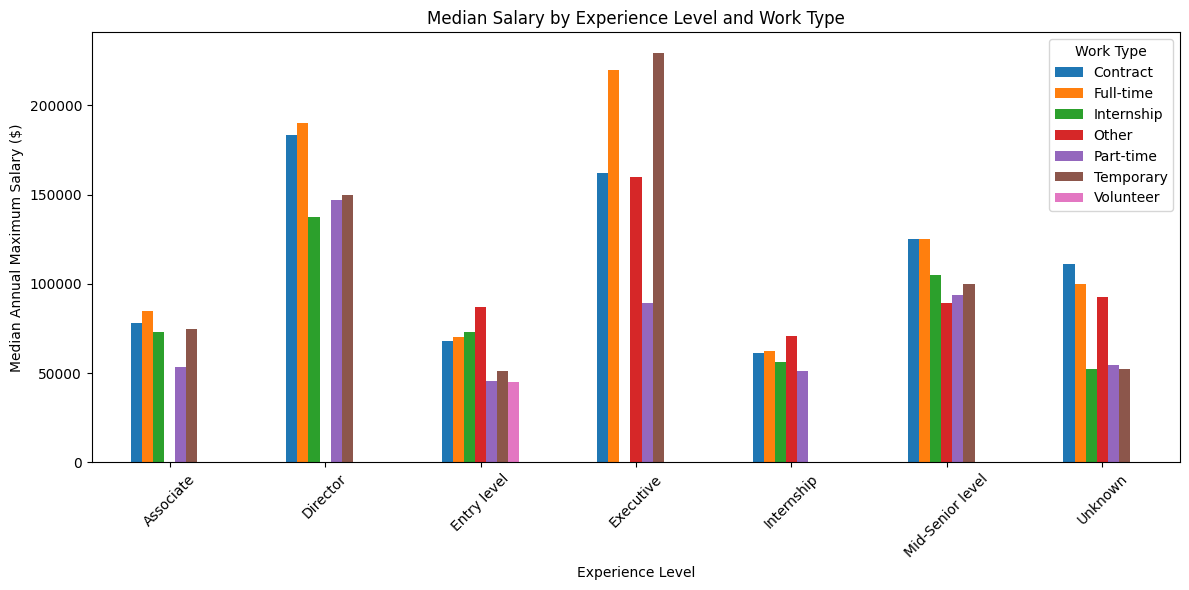

In [254]:
import matplotlib.pyplot as plt
import pandas as pd

pivot_data = salary_exp_work.pivot(
    index="formatted_experience_level",
    columns="formatted_work_type",
    values="annual_max_salary"
)

pivot_data.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Median Salary by Experience Level and Work Type")
plt.xlabel("Experience Level")
plt.ylabel("Median Annual Maximum Salary ($)")
plt.xticks(rotation=45)
plt.legend(title="Work Type")

plt.tight_layout()
plt.show()

In [255]:
top_exp_work = salary_exp_work.sort_values(
    "annual_max_salary",
    ascending=False
).head(10)
print("TOP 10 EXPERIENCE + WORK TYPE COMBINATIONS")
print("=" * 50)
print(top_exp_work)

TOP 10 EXPERIENCE + WORK TYPE COMBINATIONS
   formatted_experience_level formatted_work_type  annual_max_salary
21                  Executive           Temporary           229400.0
18                  Executive           Full-time           220000.0
6                    Director           Full-time           190000.0
5                    Director            Contract           183600.0
17                  Executive            Contract           162240.0
19                  Executive               Other           159675.0
9                    Director           Temporary           150000.0
8                    Director           Part-time           147100.0
7                    Director          Internship           137460.0
28           Mid-Senior level           Full-time           125000.0


In [256]:
salary_corr = clean_salary_data[
    ["min_salary", "max_salary", "annual_min_salary", "annual_max_salary"]
].corr()

print(salary_corr)

                   min_salary  max_salary  annual_min_salary  \
min_salary           1.000000    0.911670           0.759190   
max_salary           0.911670    1.000000           0.673889   
annual_min_salary    0.759190    0.673889           1.000000   
annual_max_salary    0.706747    0.837065           0.844343   

                   annual_max_salary  
min_salary                  0.706747  
max_salary                  0.837065  
annual_min_salary           0.844343  
annual_max_salary           1.000000  


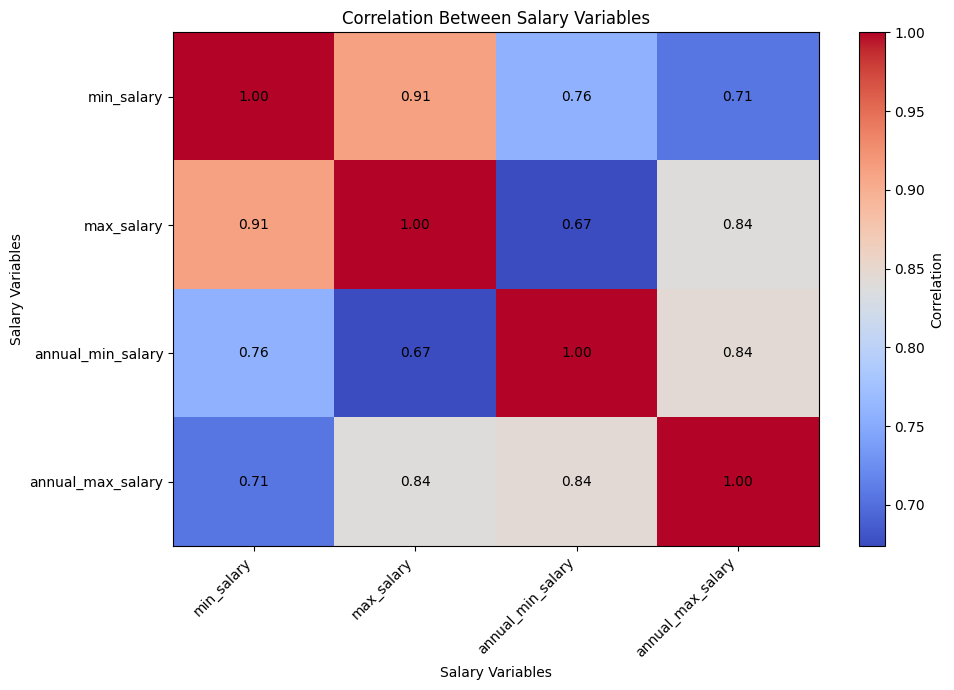

In [257]:
plt.figure(figsize=(10, 7))

plt.imshow(salary_corr, cmap="coolwarm", aspect="auto")

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(salary_corr.columns)),
    salary_corr.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(salary_corr.columns)),
    salary_corr.columns
)

for i in range(len(salary_corr)):
    for j in range(len(salary_corr.columns)):
        plt.text(
            j, i,
            f"{salary_corr.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.title("Correlation Between Salary Variables")
plt.xlabel("Salary Variables")
plt.ylabel("Salary Variables")

plt.tight_layout()
plt.show()

In [258]:
print("KEY CORRELATIONS")
print("=" * 40)
print(
    "mim salary vs max salary:",
    round(salary_corr.loc["annual_min_salary", "max_salary"], 2)
)

print(
    "annual min salary vs annual max salary:",
    round(salary_corr.loc["annual_min_salary", "annual_max_salary"], 2)
)

KEY CORRELATIONS
mim salary vs max salary: 0.67
annual min salary vs annual max salary: 0.84


In [259]:
print([col for col in clean_salary_data.columns if "remote" in col.lower()])

[]


In [260]:
print(salary_data.columns.tolist())

['job_id', 'company_name', 'title', 'location', 'max_salary', 'min_salary', 'pay_period', 'formatted_work_type', 'formatted_experience_level', 'views', 'work_type', 'currency', 'annual_max_salary', 'annual_min_salary']


In [261]:
print(clean_salary_data.columns.tolist())

['job_id', 'company_name', 'title', 'location', 'max_salary', 'min_salary', 'pay_period', 'formatted_work_type', 'formatted_experience_level', 'views', 'work_type', 'currency', 'annual_max_salary', 'annual_min_salary']


In [262]:
for col in clean_salary_data.columns:
  print(col)


job_id
company_name
title
location
max_salary
min_salary
pay_period
formatted_work_type
formatted_experience_level
views
work_type
currency
annual_max_salary
annual_min_salary


In [263]:
salary_by_company = (
    clean_salary_data
    .groupby("company_name")["annual_max_salary"]
    .agg(["count", "mean", "median"])
)

salary_by_company = (
    salary_by_company[salary_by_company["count"] >= 10]
    .sort_values("median", ascending=False)
)

print("TOP 10 COMPANIES BY MEDIAN SALARY")
print("=" * 45)
print(salary_by_company.head(10))

TOP 10 COMPANIES BY MEDIAN SALARY
                      count           mean    median
company_name                                        
Goliath Partners         10  582500.000000  550000.0
NVIDIA                   11  318340.909091  327750.0
Snowflake                15  295800.000000  327700.0
DocCafe                  15  357133.400000  325000.0
Dental Care Alliance     22  369260.954545  301755.5
Gilead Sciences          17  221955.882353  279620.0
Exelixis                 14  263053.571429  263000.0
Adobe                    23  260591.304348  262100.0
TikTok                   58  250956.327586  251540.0
The Trade Desk           13  239315.384615  249900.0


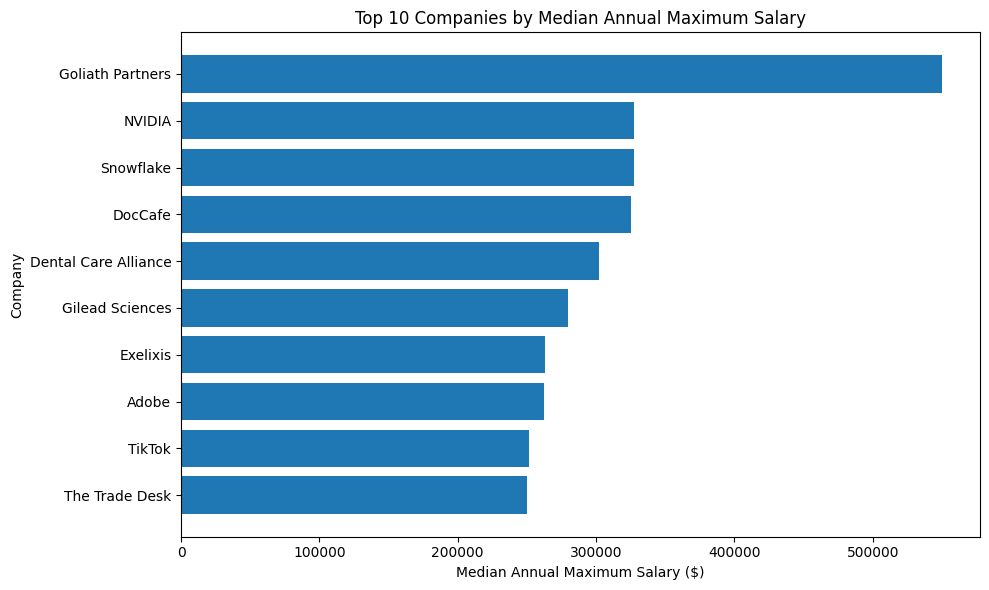

In [264]:
top_10_companies = salary_by_company.head(10).sort_values("median")

plt.figure(figsize=(10, 6))

plt.barh(
    top_10_companies.index,
    top_10_companies["median"]
)

plt.xlabel("Median Annual Maximum Salary ($)")
plt.ylabel("Company")
plt.title("Top 10 Companies by Median Annual Maximum Salary")

plt.tight_layout()
plt.show()

In [265]:
views_by_title = (
    clean_salary_data
    .groupby("title")
    .agg(
        job_postings=("title", "count"),
        total_views=("views", "sum"),
        median_salary=("annual_max_salary", "median")
    )
    .sort_values("total_views", ascending=False)
)

print("TOP 10 MOST VIEWED JOB TITLES")
print("=" * 45)
print(views_by_title.head(10))

TOP 10 MOST VIEWED JOB TITLES
                                    job_postings  total_views  median_salary
title                                                                       
Executive Administrative Assistant            17      10412.0        70000.0
Executive Assistant                           87      10401.0        89440.0
Senior Business Operations Manager             2       9979.0       181700.0
Data Analyst                                  34       5313.0        95000.0
Project Manager                              112       5038.0       121320.0
Executive Assistant CPO                        1       4951.0        85280.0
VP, Health Plan Account Management             1       4807.0       350000.0
Social Media Manager                           6       4472.0        90000.0
Junior Account Executive                      10       4471.0        70000.0
Software Engineer                             58       4409.0       152500.0


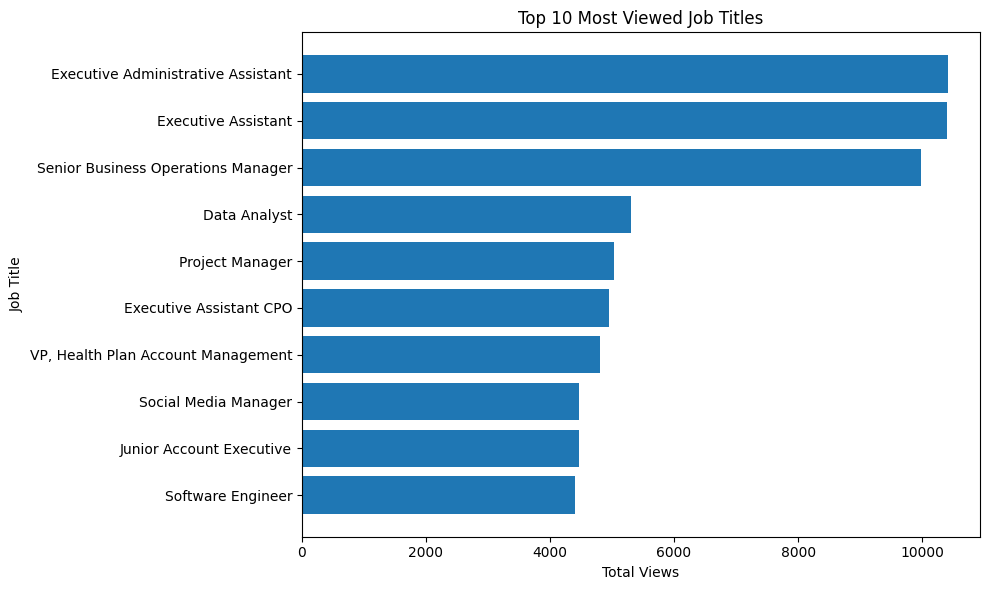

In [266]:
top_viewed_titles = views_by_title.head(10).sort_values("total_views")

plt.figure(figsize=(10, 6))

plt.barh(
    top_viewed_titles.index,
    top_viewed_titles["total_views"]
)

plt.xlabel("Total Views")
plt.ylabel("Job Title")
plt.title("Top 10 Most Viewed Job Titles")

plt.tight_layout()
plt.show()

In [267]:
print(clean_salary_data.columns.tolist())

['job_id', 'company_name', 'title', 'location', 'max_salary', 'min_salary', 'pay_period', 'formatted_work_type', 'formatted_experience_level', 'views', 'work_type', 'currency', 'annual_max_salary', 'annual_min_salary']


In [268]:
salary_by_work_type = (
    clean_salary_data
    .groupby("formatted_work_type")["annual_max_salary"]
    .agg(["count", "mean", "median"])
    .sort_values("median", ascending=False)
)

print("SALARY BY WORK TYPE")
print("=" * 40)
print(salary_by_work_type)

SALARY BY WORK TYPE
                     count           mean    median
formatted_work_type                                
Contract              3132  115095.867890  108160.0
Full-time            24261  122910.994689  105000.0
Other                   89  120640.816966   89440.0
Temporary              273   93082.926007   72800.0
Internship             133   70479.439098   58240.0
Part-time             1467   74811.882345   52478.4
Volunteer                1   44850.000000   44850.0


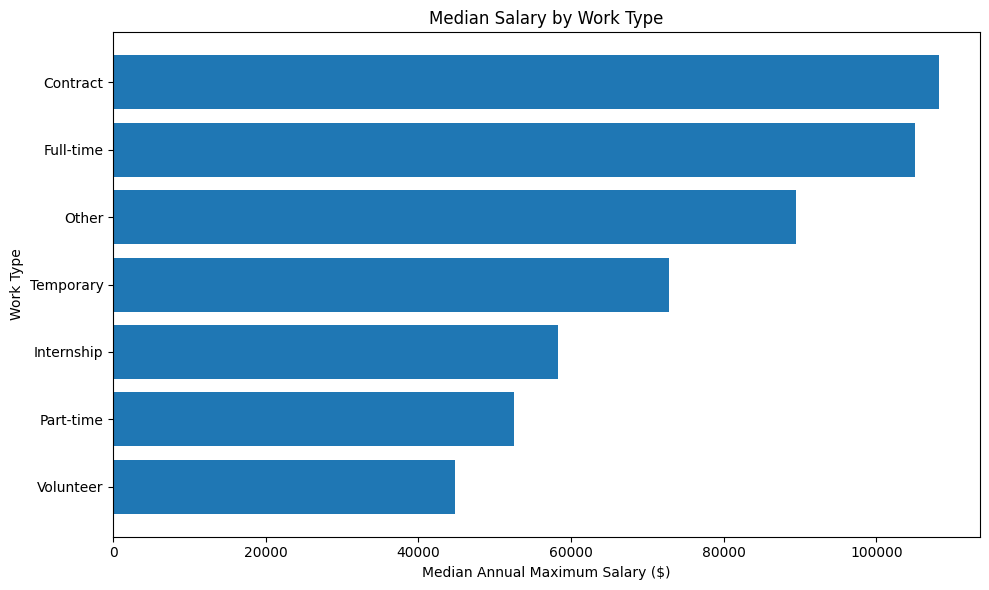

In [269]:
work_type_plot = salary_by_work_type.sort_values("median")

plt.figure(figsize=(10, 6))

plt.barh(
    work_type_plot.index,
    work_type_plot["median"]
)

plt.xlabel("Median Annual Maximum Salary ($)")
plt.ylabel("Work Type")
plt.title("Median Salary by Work Type")

plt.tight_layout()
plt.show()

In [270]:
salary_by_location = (
    clean_salary_data
    .groupby("location")["annual_max_salary"]
    .agg(["count", "mean", "median"])
    .sort_values("median", ascending=False)
)

print("SALARY BY LOCATION")
print("=" * 40)
print(salary_by_location.head(10))

SALARY BY LOCATION
                                  count      mean    median
location                                                   
Orange Park, FL                       1  800000.0  800000.0
Chicago, Illinois, United States      1  800000.0  800000.0
Annandale, VA                         1  700000.0  700000.0
Greenlawn, NY                         1  645000.0  645000.0
Olympia Fields, IL                    1  580000.0  580000.0
West Islip, NY                        1  573917.0  573917.0
Tuscaloosa, AL                        2  532500.0  532500.0
Cape Canaveral, FL                    1  500000.0  500000.0
Markham, IL                           1  500000.0  500000.0
Wheeling, IL                          2  495000.0  495000.0


In [271]:
job_title_counts = (
    clean_salary_data
    .groupby("title")
    .agg(job_postings=("title", "count"))
    .sort_values("job_postings", ascending=False)
)

print("TOP 10 MOST COMMON JOB TITLES")
print("=" * 40)
print(job_title_counts.head(10))

TOP 10 MOST COMMON JOB TITLES
                          job_postings
title                                 
Senior Accountant                  130
Project Manager                    112
Staff Accountant                   103
Controller                          94
Administrative Assistant            90
Executive Assistant                 87
Accounting Manager                  62
Accountant                          59
Software Engineer                   58
Senior Software Engineer            57


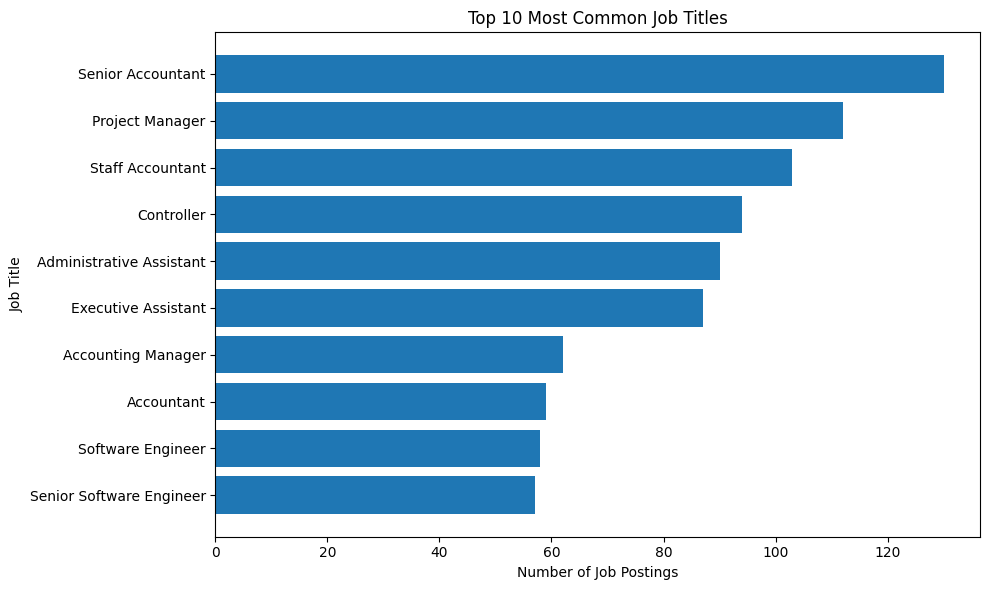

In [272]:
top_common_jobs = job_title_counts.head(10).sort_values("job_postings")

plt.figure(figsize=(10, 6))

plt.barh(
    top_common_jobs.index,
    top_common_jobs["job_postings"]
)

plt.xlabel("Number of Job Postings")
plt.ylabel("Job Title")
plt.title("Top 10 Most Common Job Titles")

plt.tight_layout()
plt.show()

In [274]:

import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
df = clean_salary_data.copy()
print("=" * 70)
print("        DATA SCIENCE JOB SALARY ANALYSIS DASHBOARD")
print("=" * 70)
total_jobs = len(df)

median_salary = df["annual_max_salary"].median()

average_salary = df["annual_max_salary"].mean()

highest_salary = df["annual_max_salary"].max()

print(f"\n📌 Total Job Postings     : {total_jobs:,}")
print(f"💰 Average Annual Salary  : ${average_salary:,.0f}")
print(f"💵 Median Annual Salary   : ${median_salary:,.0f}")
print(f"🏆 Highest Annual Salary  : ${highest_salary:,.0f}")
top_titles = (
    df.groupby("title")
    .agg(
        job_postings=("title", "count"),
        median_salary=("annual_max_salary", "median")
    )
    .sort_values("job_postings", ascending=False)
    .head(10)
    .reset_index()
)
work_type_salary = (
    df.groupby("formatted_work_type")["annual_max_salary"]
    .median()
    .sort_values(ascending=False)
    .reset_index()
)
experience_salary = (
    df.groupby("formatted_experience_level")["annual_max_salary"]
    .median()
    .sort_values(ascending=False)
    .reset_index()
)
top_locations = (
    df.groupby("location")
    .agg(
        job_postings=("location", "count"),
        median_salary=("annual_max_salary", "median")
    )
    .sort_values("job_postings", ascending=False)
    .head(10)
    .reset_index()
)
fig = make_subplots(
    rows=2,
    cols=2,
    subplot_titles=(
        "Top 10 Job Titles by Number of Postings",
        "Median Salary by Work Type",
        "Median Salary by Experience Level",
        "Top 10 Job Locations"
    ),
    vertical_spacing=0.15,
    horizontal_spacing=0.10
)
fig.add_trace(
    go.Bar(
        x=top_titles["job_postings"],
        y=top_titles["title"],
        orientation="h",
        name="Job Postings"
    ),
    row=1,
    col=1
)
fig.add_trace(
    go.Bar(
        x=work_type_salary["formatted_work_type"],
        y=work_type_salary["annual_max_salary"],
        name="Median Salary"
    ),
    row=1,
    col=2
)
fig.add_trace(
    go.Bar(
        x=experience_salary["formatted_experience_level"],
        y=experience_salary["annual_max_salary"],
        name="Median Salary"
    ),
    row=2,
    col=1
)
fig.add_trace(
    go.Bar(
        x=top_locations["job_postings"],
        y=top_locations["location"],
        orientation="h",
        name="Job Postings"
    ),
    row=2,
    col=2
)
fig.update_layout(
    title={
        "text": "📊 Data Science Job Salary Analysis Dashboard",
        "x": 0.5,
        "xanchor": "center"
    },
    height=900,
    width=1200,
    showlegend=False,
    template="plotly_white"
)

fig.update_xaxes(title_text="Number of Job Postings", row=1, col=1)
fig.update_yaxes(title_text="Job Title", row=1, col=1)

fig.update_xaxes(title_text="Work Type", row=1, col=2)
fig.update_yaxes(title_text="Median Annual Salary ($)", row=1, col=2)

fig.update_xaxes(title_text="Experience Level", row=2, col=1)
fig.update_yaxes(title_text="Median Annual Salary ($)", row=2, col=1)

fig.update_xaxes(title_text="Number of Job Postings", row=2, col=2)
fig.update_yaxes(title_text="Location", row=2, col=2)

fig.show()

        DATA SCIENCE JOB SALARY ANALYSIS DASHBOARD

📌 Total Job Postings     : 29,356
💰 Average Annual Salary  : $119,149
💵 Median Annual Salary   : $103,000
🏆 Highest Annual Salary  : $1,000,000


# 📊 Interactive Salary Analysis Dashboard

This dashboard provides an interactive overview of job salary trends across job titles, work types, experience levels, and locations.

The dashboard helps identify:
- Most common job titles
- Salary differences by work type
- Salary differences by experience level
- Locations with the highest number of job postings


1. **Salary Distribution**
   - Most job postings have annual maximum salaries concentrated in the lower-to-middle salary range.
   - The salary distribution is right-skewed because a small number of jobs offer extremely high salaries.

2. **Highest-Paying Jobs**
   - Several senior-level and specialized positions have annual maximum salaries reaching very high values.
   - Leadership, technology, legal, and specialized professional roles appear among the highest-paying positions.

3. **Work Type**
   - Contract and full-time positions have the highest median annual maximum salaries.
   - Internship and volunteer positions have comparatively lower median salaries.

4. **Experience Level**
   - Executive-level positions have the highest median annual maximum salary.
   - Director and Mid-Senior-level positions also show significantly higher salaries.
   - Entry-level and internship positions have the lowest median salaries.

5. **Location**
   - Locations such as Mountain View, Sunnyvale, San Jose, Palo Alto, and the San Francisco Bay Area show some of the highest median salaries.
   - This indicates that major technology hubs tend to have higher-paying job opportunities.

6. **Salary Correlation**
   - Minimum salary and maximum salary have a strong positive correlation of **0.67**.
   - Annual minimum and annual maximum salary have a strong correlation of **0.84**.
   - This indicates that jobs offering higher minimum salaries generally also offer higher maximum salaries.


The analysis shows that **experience level, work type, job role, and location are important factors associated with salary levels**. Senior and executive positions generally offer higher salaries, while entry-level and internship positions have lower salary ranges. Major technology and business hubs also tend to offer higher compensation.

This exploratory data analysis provides useful insights into salary patterns and can help job seekers, recruiters, and organizations understand compensation trends in the job market.